In [1]:
pip install pandas

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.9 MB 7.0 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.9 MB 8.1 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.9 MB 9.0 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 10.2 MB/s  0:00:01
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   -------- ------------------------------- 2.6/12.5 MB 13.2 MB/s eta 0:00:01
   ---------------- ----------------------- 5.2/12.5 MB 13.0 MB/s eta 0:00:01
   -------------------------- ------------- 8.1/12.5 MB 13.5 MB/s eta 0:00:01
   ------------------------------------ --- 11.3/12.5 MB 13.6 MB/s eta 0:00:01
   ---------------------------------------- 12.5/12.5 MB 13.1 MB/s  0:00:00

   ---------------------------------------- 0/2 [numpy]
   ----------------------------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Ambri\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [10]:
pip install   matplotlib seaborn scikit-learn

  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl (2.


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Ambri\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

df = pd.read_csv("Telco Customer Churn.csv")

print(df.head())
print(df.shape)
print(df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [4]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [5]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

C:\Users\Ambri\AppData\Local\Temp\ipykernel_5400\575980950.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"].fillna(


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [6]:
churn_rate = (
    df["Churn"]
    .value_counts(normalize=True)
    *100
)

print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [7]:
pd.crosstab(
    df["Contract"],
    df["Churn"]
)

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [8]:
pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


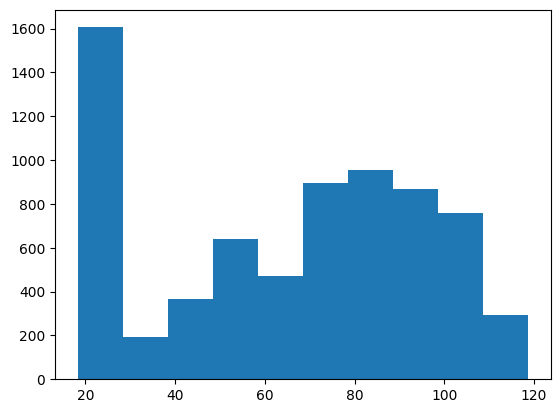

In [13]:
import matplotlib.pyplot as plt

plt.hist(df["MonthlyCharges"])
plt.show()

In [14]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Ambri\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip
